In [ ]:
# TASK 1: COLLECT STUDENT FEEDBACK DATA

# Import pandas
import pandas as pd

# Create student feedback data
data = {
    "Student_ID": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        11, 12, 13, 14, 15
    ],

    "Department": [
        "MCA", "MCA", "BCA", "BCA", "MCA",
        "BCA", "MCA", "BCA", "MCA", "BCA",
        "MCA", "BCA", "MCA", "BCA", "MCA"
    ],

    "Feedback": [
        "The teacher explains concepts very clearly",
        "The subject is difficult and needs more examples",
        "The classroom activities are very interesting",
        "The teaching speed is too fast",
        "I am happy with the teaching method",
        "The laboratory needs better computers",
        "The teacher is helpful and supportive",
        "There are too many assignments",
        "The lectures are interesting and easy to understand",
        "The classroom is sometimes noisy",
        "More practical classes are needed",
        "The teacher explains topics clearly",
        "The subject content is difficult",
        "More interactive activities should be conducted",
        "The overall learning experience is good"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display first 5 rows
print("Student Feedback Dataset:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Save dataset
df.to_csv("student_feedback.csv", index=False)

print("\nDataset saved successfully!")

Student Feedback Dataset:
   Student_ID Department                                          Feedback
0           1        MCA        The teacher explains concepts very clearly
1           2        MCA  The subject is difficult and needs more examples
2           3        BCA     The classroom activities are very interesting
3           4        BCA                    The teaching speed is too fast
4           5        MCA               I am happy with the teaching method

Dataset Shape:
(15, 3)

Dataset saved successfully!


In [ ]:
# TASK 2: PREPROCESS FEEDBACK TEXT

# Import libraries
import re
import nltk

# Download stopwords
nltk.download("stopwords")

# Import stopwords
from nltk.corpus import stopwords

# Get English stopwords
stop_words = set(stopwords.words("english"))


# Create cleaning function
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join words
    return " ".join(words)


# Create cleaned feedback column
df["Clean_Feedback"] = df["Feedback"].apply(clean_text)

# Display original and cleaned feedback
print("Cleaned Feedback:")

print(
    df[
        ["Feedback", "Clean_Feedback"]
    ].head(10)
)

Cleaned Feedback:
                                            Feedback  \
0         The teacher explains concepts very clearly   
1   The subject is difficult and needs more examples   
2      The classroom activities are very interesting   
3                     The teaching speed is too fast   
4                I am happy with the teaching method   
5              The laboratory needs better computers   
6              The teacher is helpful and supportive   
7                     There are too many assignments   
8  The lectures are interesting and easy to under...   
9                   The classroom is sometimes noisy   

                         Clean_Feedback  
0     teacher explains concepts clearly  
1      subject difficult needs examples  
2      classroom activities interesting  
3                   teaching speed fast  
4                 happy teaching method  
5     laboratory needs better computers  
6            teacher helpful supportive  
7                      many a

[nltk_data] Downloading package stopwords to C:\Users\ullas gowda
[nltk_data]     bu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# TASK 3: SENTIMENT ANALYSIS

# Import TextBlob
from textblob import TextBlob


# Create sentiment function
def get_sentiment(text):

    # Calculate polarity
    score = TextBlob(text).sentiment.polarity

    # Positive sentiment
    if score > 0:
        return "Positive"

    # Negative sentiment
    elif score < 0:
        return "Negative"

    # Neutral sentiment
    else:
        return "Neutral"


# Apply sentiment analysis
df["Sentiment"] = df["Feedback"].apply(
    get_sentiment
)

# Display results
print("Student Sentiment:")

print(
    df[
        ["Student_ID", "Feedback", "Sentiment"]
    ]
)

Student Sentiment:
    Student_ID                                           Feedback Sentiment
0            1         The teacher explains concepts very clearly  Positive
1            2   The subject is difficult and needs more examples  Negative
2            3      The classroom activities are very interesting  Positive
3            4                     The teaching speed is too fast  Positive
4            5                I am happy with the teaching method  Positive
5            6              The laboratory needs better computers  Positive
6            7              The teacher is helpful and supportive  Positive
7            8                     There are too many assignments  Positive
8            9  The lectures are interesting and easy to under...  Positive
9           10                   The classroom is sometimes noisy   Neutral
10          11                  More practical classes are needed  Positive
11          12                The teacher explains topics clearly  Po

In [ ]:
# TASK 4: IDENTIFY COMMON CONCERNS

# List of common concerns
concerns = [
    "difficult",
    "assignments",
    "speed",
    "computer",
    "laboratory",
    "practical",
    "noisy",
    "examples",
    "interactive",
    "activities"
]

# Create empty list
results = []

# Count each concern
for concern in concerns:

    count = df["Clean_Feedback"].str.contains(
        concern,
        case=False,
        na=False
    ).sum()

    results.append(
        [concern, count]
    )


# Create DataFrame
concern_df = pd.DataFrame(
    results,
    columns=["Concern", "Mentions"]
)

# Sort by number of mentions
concern_df = concern_df.sort_values(
    by="Mentions",
    ascending=False
)

# Display concerns
print("Common Student Concerns:")
print(concern_df)

Common Student Concerns:
       Concern  Mentions
0    difficult         2
9   activities         2
1  assignments         1
2        speed         1
4   laboratory         1
3     computer         1
5    practical         1
6        noisy         1
7     examples         1
8  interactive         1


In [ ]:
# TASK 5: IMPROVEMENT SUGGESTIONS

# Find the most common concern
main_concern = concern_df.iloc[0]["Concern"]

# Display suggestions
print("==========================================")
print("       IMPROVEMENT SUGGESTIONS")
print("==========================================")

print(
    "Main Student Concern:",
    main_concern
)

print("\nSuggestions:")

print(
    "1. Provide more practical classes."
)

print(
    "2. Use more examples while teaching."
)

print(
    "3. Conduct interactive classroom activities."
)

print(
    "4. Provide better laboratory facilities."
)

print(
    "5. Balance the number of assignments."
)

print(
    "6. Improve classroom learning environment."
)

print("==========================================")

       IMPROVEMENT SUGGESTIONS
Main Student Concern: difficult

Suggestions:
1. Provide more practical classes.
2. Use more examples while teaching.
3. Conduct interactive classroom activities.
4. Provide better laboratory facilities.
5. Balance the number of assignments.
6. Improve classroom learning environment.


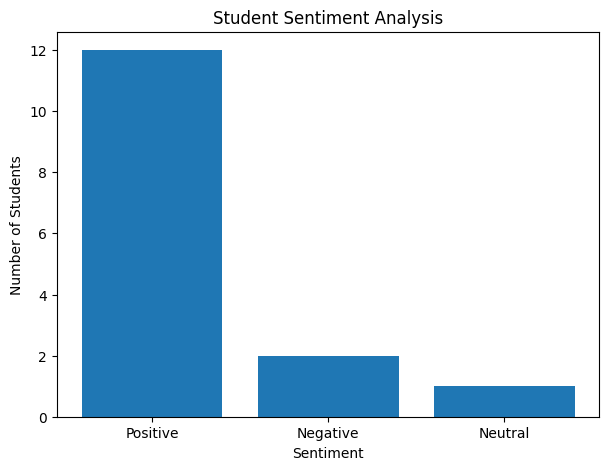

In [ ]:
# SENTIMENT VISUALIZATION

import matplotlib.pyplot as plt

# Count sentiments
sentiment_count = df["Sentiment"].value_counts()

# Create bar graph
plt.figure(figsize=(7, 5))

plt.bar(
    sentiment_count.index,
    sentiment_count.values
)

# Add title
plt.title("Student Sentiment Analysis")

# Add labels
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")

# Show graph
plt.show()

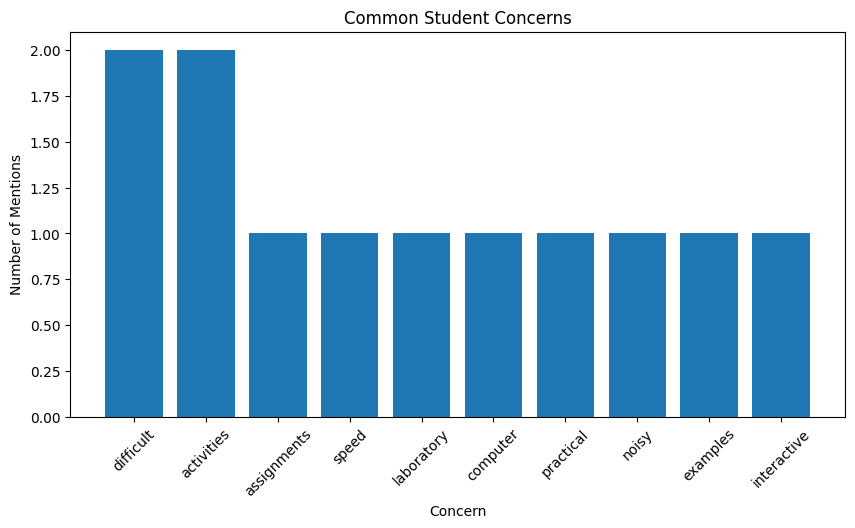

In [ ]:
# COMMON CONCERNS VISUALIZATION

import matplotlib.pyplot as plt

# Create graph
plt.figure(figsize=(10, 5))

plt.bar(
    concern_df["Concern"],
    concern_df["Mentions"]
)

# Add title
plt.title("Common Student Concerns")

# Add labels
plt.xlabel("Concern")
plt.ylabel("Number of Mentions")

# Rotate labels
plt.xticks(rotation=45)

# Show graph
plt.show()

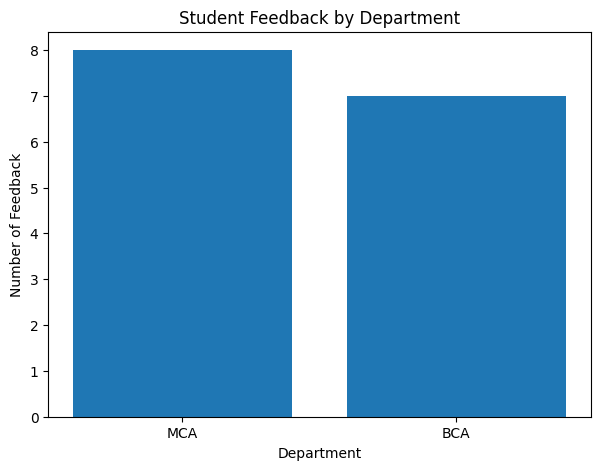

In [ ]:
# DEPARTMENT FEEDBACK

# Count feedback by department
department_count = df["Department"].value_counts()

# Create graph
plt.figure(figsize=(7, 5))

plt.bar(
    department_count.index,
    department_count.values
)

# Add title
plt.title("Student Feedback by Department")

# Add labels
plt.xlabel("Department")
plt.ylabel("Number of Feedback")

# Show graph
plt.show()

Sentiment   Negative  Neutral  Positive
Department                             
BCA                0        1         6
MCA                2        0         6


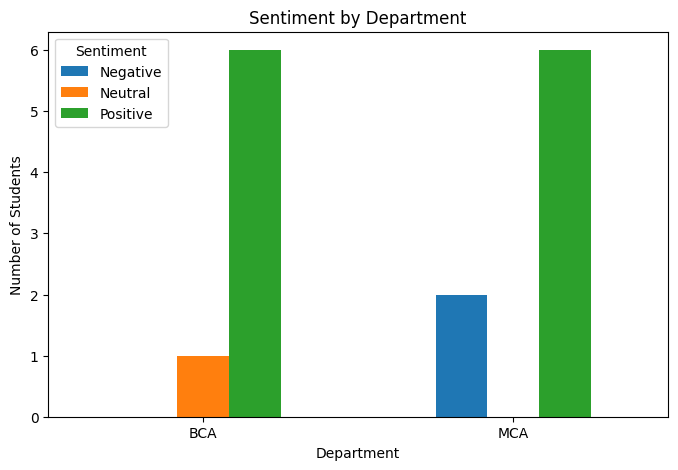

In [ ]:
# SENTIMENT BY DEPARTMENT

# Create cross-tabulation
department_sentiment = pd.crosstab(
    df["Department"],
    df["Sentiment"]
)

# Display table
print(department_sentiment)

# Create graph
department_sentiment.plot(
    kind="bar",
    figsize=(8, 5)
)

# Add title
plt.title("Sentiment by Department")

# Add labels
plt.xlabel("Department")
plt.ylabel("Number of Students")

# Show graph
plt.xticks(rotation=0)

# Show graph
plt.show()

In [ ]:
# PROJECT SUMMARY

print("==========================================")
print("       STUDENT FEEDBACK ANALYSIS")
print("==========================================")

print("1. Student feedback data collected")
print("2. Feedback text preprocessed")
print("3. Student sentiment analyzed")
print("4. Common student concerns identified")
print("5. Improvement suggestions prepared")
print("6. Visualizations created")

print("==========================================")
print("       PROJECT COMPLETED")
print("==========================================")